In [ ]:
!git clone https://github.com/shuvo-iitkgp/heavy-tailed-kmeans.git

Cloning into 'heavy-tailed-kmeans'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 86 (delta 12), reused 48 (delta 9), pack-reused 31 (from 1)
Receiving objects: 100% (86/86), 41.70 MiB | 15.71 MiB/s, done.
Resolving deltas: 100% (18/18), done.


In [ ]:
%cd heavy-tailed-kmeans


/content/heavy-tailed-kmeans


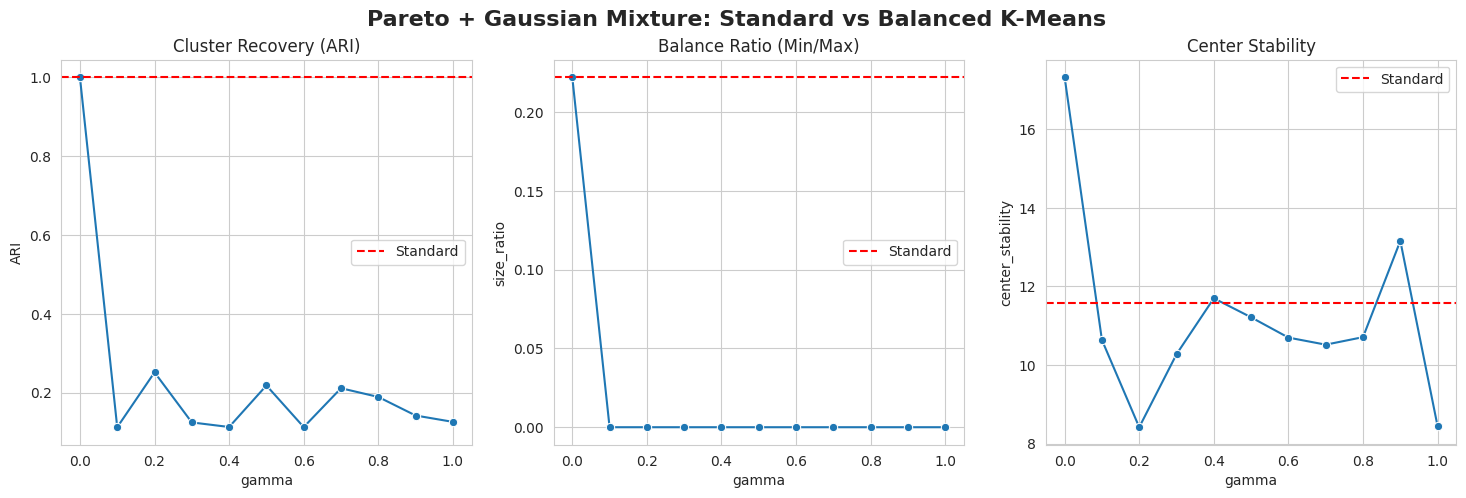

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pareto
from sklearn.metrics import adjusted_rand_score

sns.set_style("whitegrid")

def generate_pareto_mixture(n_samples, proportions, centers, pareto_alpha=2.0, noise_std=0.5, dimension=2):
    k = len(proportions)
    cluster_sizes = [int(n_samples * p) for p in proportions]
    cluster_sizes[-1] = n_samples - sum(cluster_sizes[:-1])
    X, y_true = [], []
    for i, (size, center) in enumerate(zip(cluster_sizes, centers)):
        if i == 0:  # Pareto cluster
            radii = pareto.rvs(pareto_alpha, size=size)
            angles = np.random.uniform(0, 2*np.pi, size)
            points = np.column_stack([center[0] + radii * np.cos(angles), center[1] + radii * np.sin(angles)])
        else:  # Gaussian clusters
            points = np.random.randn(size, dimension) * noise_std + center
        X.append(points)
        y_true.extend([i] * size)
    X = np.vstack(X)
    y_true = np.array(y_true)
    idx = np.random.permutation(n_samples)
    return X[idx], y_true[idx]

def standard_kmeans(X, k, max_iter=100):
    n = len(X)
    centers = X[np.random.choice(n, k, replace=False)]
    labels = np.zeros(n, dtype=int)
    for _ in range(max_iter):
        dists = np.sum((X[:, np.newaxis, :] - centers[np.newaxis, :, :]) ** 2, axis=2)
        labels = np.argmin(dists, axis=1)
        new_centers = np.array([X[labels == j].mean(axis=0) if np.sum(labels == j) > 0 else centers[j] for j in range(k)])
        if np.allclose(centers, new_centers):
            break
        centers = new_centers
    inertia = np.sum([np.sum((X[labels == j] - centers[j]) ** 2) for j in range(k)])
    return labels, centers, inertia

def balanced_kmeans(X, k, gamma, max_iter=100):
    n = len(X)
    target_size = n / k
    centers = X[np.random.choice(n, k, replace=False)]
    labels = np.zeros(n, dtype=int)
    for _ in range(max_iter):
        dists = np.sum((X[:, np.newaxis, :] - centers[np.newaxis, :, :]) ** 2, axis=2)
        cluster_sizes = np.zeros(k)
        for idx in np.argsort(np.min(dists, axis=1)):
            balance_penalty = gamma * (cluster_sizes - target_size) ** 2
            adjusted_dists = dists[idx] + balance_penalty
            labels[idx] = np.argmin(adjusted_dists)
            cluster_sizes[labels[idx]] += 1
        new_centers = np.array([X[labels == j].mean(axis=0) if np.sum(labels == j) > 0 else centers[j] for j in range(k)])
        if np.allclose(centers, new_centers):
            break
        centers = new_centers
    inertia = np.sum([np.sum((X[labels == j] - centers[j]) ** 2) for j in range(k)])
    return labels, centers, inertia

def experiment(n_samples=2000, k=3, gamma_values=None):
    if gamma_values is None:
        gamma_values = np.linspace(0, 1, 11)
    proportions = [0.1] + [0.9/(k-1)]*(k-1)
    angle_step = 2 * np.pi / k
    radius = 10
    centers_true = [np.array([radius * np.cos(i * angle_step), radius * np.sin(i * angle_step)]) for i in range(k)]
    X, y_true = generate_pareto_mixture(n_samples, proportions, centers_true)
    results = []
    labels_std, centers_std, inertia_std = standard_kmeans(X, k)
    ari_std = adjusted_rand_score(y_true, labels_std)
    cluster_sizes_std = [np.sum(labels_std == i) for i in range(k)]
    center_stability_std = np.mean([np.linalg.norm(centers_std[i] - centers_true[i]) for i in range(k)])
    results.append({'method': 'Standard', 'gamma': 0, 'ARI': ari_std, 'min_size': min(cluster_sizes_std),
                    'size_ratio': min(cluster_sizes_std)/max(cluster_sizes_std), 'inertia': inertia_std,
                    'center_stability': center_stability_std})
    for gamma in gamma_values:
        labels_bal, centers_bal, inertia_bal = balanced_kmeans(X, k, gamma)
        ari_bal = adjusted_rand_score(y_true, labels_bal)
        cluster_sizes_bal = [np.sum(labels_bal == i) for i in range(k)]
        center_stability_bal = np.mean([np.linalg.norm(centers_bal[i] - centers_true[i]) for i in range(k)])
        results.append({'method': 'Balanced', 'gamma': gamma, 'ARI': ari_bal, 'min_size': min(cluster_sizes_bal),
                        'size_ratio': min(cluster_sizes_bal)/max(cluster_sizes_bal), 'inertia': inertia_bal,
                        'center_stability': center_stability_bal})
    df = pd.DataFrame(results)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.lineplot(data=df[df['method'] == 'Balanced'], x='gamma', y='ARI', ax=axes[0], marker='o')
    axes[0].axhline(ari_std, color='red', linestyle='--', label='Standard')
    axes[0].set_title('Cluster Recovery (ARI)')
    axes[0].legend()
    sns.lineplot(data=df[df['method'] == 'Balanced'], x='gamma', y='size_ratio', ax=axes[1], marker='o')
    axes[1].axhline(results[0]['size_ratio'], color='red', linestyle='--', label='Standard')
    axes[1].set_title('Balance Ratio (Min/Max)')
    axes[1].legend()
    sns.lineplot(data=df[df['method'] == 'Balanced'], x='gamma', y='center_stability', ax=axes[2], marker='o')
    axes[2].axhline(results[0]['center_stability'], color='red', linestyle='--', label='Standard')
    axes[2].set_title('Center Stability')
    axes[2].legend()
    plt.suptitle('Pareto + Gaussian Mixture: Standard vs Balanced K-Means', fontsize=16, fontweight='bold')
    plt.show()
    return df

df_results = experiment(n_samples=2000, k=3)
